# 06 Global-average-pool Grad-CAM XAI
This notebook implements Gradient-weighted Class Activation Mapping (Grad-CAM) to provide visual explanations for the pneumonia classifier. It highlights the regions of the X-ray image that most influence the model's prediction.

In [2]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

from pneumonia_classifier.ml.model.arch import Net

## Load Model and Weights

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net().to(device)

# Load weights from the trained model
weights_path = 'model_v1.pt'
try:
    model.load_state_dict(torch.load(weights_path, map_location=device))
    print("Model weights loaded successfully.")
except:
    # Fallback for full model load
    model = torch.load(weights_path, map_location=device)
    print("Full model loaded successfully.")

model.eval()

Model weights loaded successfully.


Net(
  (convolution_block1): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (pooling11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (convolution_block2): Sequential(
    (0): Conv2d(8, 20, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (pooling22): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (convolution_block3): Sequential(
    (0): Conv2d(20, 10, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (pooling33): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (convolution_block4): Sequential(
    (0): Conv2d(10, 20, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2

## Grad-CAM Implementation
We use hooks to extract gradients and activations from the last convolutional layer (`convolution_block9`).

In [4]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_tensor, class_idx=None):
        # Forward pass
        output = self.model(input_tensor)
        
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
            
        self.model.zero_grad()
        # Backward pass for the specific class
        output[0, class_idx].backward()
        
        # Pool the gradients
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        
        # Weighted sum of activations
        cam = torch.sum(weights * self.activations, dim=1).squeeze()
        
        # ReLU to keep only positive influence
        cam = F.relu(cam)
        
        # Normalize
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-7)
        
        return cam.detach().cpu().numpy(), class_idx

## Process and Visualize

j:\Users\ayush\Desktop\code\pneumonia_classifier\.venv\lib\site-packages\torch\nn\modules\module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


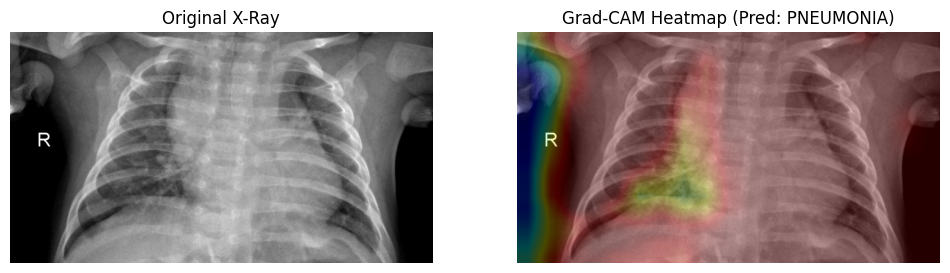

In [6]:
def apply_heatmap(img_path, heatmap):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize heatmap to match image size
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    # Overlay
    superimposed_img = heatmap * 0.4 + img
    # Rescale to 0-255
    superimposed_img = superimposed_img / superimposed_img.max() * 255
    
    return np.uint8(superimposed_img)

# Sample test
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Pick a pneumonia sample
sample_img_path = r'J:\Users\ayush\Desktop\code\pneumonia_classifier\artifacts\02_12_2025_08_52_04\data_ingestion\data\data\test\PNEUMONIA\person18_virus_49.jpeg'

if os.path.exists(sample_img_path):
    img = Image.open(sample_img_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)
    
    grad_cam = GradCAM(model, model.convolution_block9)
    heatmap, pred_idx = grad_cam.generate_heatmap(input_tensor)
    
    result_img = apply_heatmap(sample_img_path, heatmap)
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original X-Ray")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(result_img)
    plt.title(f"Grad-CAM Heatmap (Pred: {'PNEUMONIA' if pred_idx == 1 else 'NORMAL'})")
    plt.axis('off')
    
    plt.show()
else:
    print("Sample image not found.")